In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss, roc_auc_score, RocCurveDisplay
from sklearn.calibration import calibration_curve

df_v1 = pd.read_parquet("data/shots_features.parquet")
df_v2 = pd.read_parquet("data/shots_features_v2.parquet")

FEATURES_V1 = ["distance", "angle", "is_header", "is_open_play"]
FEATURES_V2 = [
    "distance", "angle", "is_header", "is_open_play", "is_penalty",
    "goalkeeper_coverage", "goalkeeper_coverage_available",
    "defenders_in_lane", "defenders_in_lane_available"
]
TARGET = "is_goal"

print(df_v1[FEATURES_V1 + [TARGET]].describe())
print(f"\nShape: {df_v1.shape}")
print(f"\nNull counts:\n{df_v1[FEATURES_V1 + [TARGET]].isnull().sum()}")

print(df_v2[FEATURES_V2 + [TARGET]].describe())
print(f"\nShape: {df_v2.shape}")
print(f"\nNull counts:\n{df_v2[FEATURES_V2 + [TARGET]].isnull().sum()}")

          distance        angle    is_header  is_open_play      is_goal
count  9168.000000  9168.000000  9168.000000   9168.000000  9168.000000
mean     19.046284    25.386265     0.163067      0.944699     0.110602
std       8.685988    15.697708     0.369447      0.228579     0.313656
min       0.632456     0.299683     0.000000      0.000000     0.000000
25%      12.000417    15.114400     0.000000      1.000000     0.000000
50%      18.261709    19.682607     0.000000      1.000000     0.000000
75%      25.269300    31.536490     0.000000      1.000000     0.000000
max      74.867416   179.999260     1.000000      1.000000     1.000000

Shape: (9168, 12)

Null counts:
distance        0
angle           0
is_header       0
is_open_play    0
is_goal         0
dtype: int64
          distance        angle    is_header  is_open_play  is_penalty  \
count  9168.000000  9168.000000  9168.000000   9168.000000  9168.00000   
mean     19.046284    25.386265     0.163067      0.944699     0.010

In [5]:
X1 = df_v1[FEATURES_V1]
X2 = df_v2[FEATURES_V2]
Y = df_v1[TARGET]

X1_train, X1_test, X2_train, X2_test, Y_train, Y_test = train_test_split(
    X1, X2, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

print(f"Train: {X1_train.shape[0]} shots, {Y_train.sum()} goals ({Y_train.mean():.3f})")
print(f"Test:  {X1_test.shape[0]} shots, {Y_test.sum()} goals ({Y_test.mean():.3f})")

print(f"Train: {X2_train.shape[0]} shots, {Y_train.sum()} goals ({Y_train.mean():.3f})")
print(f"Test:  {X2_test.shape[0]} shots, {Y_test.sum()} goals ({Y_test.mean():.3f})")

Train: 7334 shots, 811 goals (0.111)
Test:  1834 shots, 203 goals (0.111)
Train: 7334 shots, 811 goals (0.111)
Test:  1834 shots, 203 goals (0.111)


In [3]:
model_v1 = LogisticRegression(max_iter=1000, random_state=42)
model_v1.fit(X1_train, Y_train)
Y_prob_v1 = model_v1.predict_proba(X1_test)[:, 1]

In [6]:
model_v2 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
model_v2.fit(X2_train, Y_train)
Y_prob_v2 = model_v2.predict_proba(X2_test)[:, 1]

In [7]:
brier_v1 = brier_score_loss(Y_test, Y_prob_v1)
brier_v2 = brier_score_loss(Y_test, Y_prob_v2)
auc_v1 = roc_auc_score(Y_test, Y_prob_v1)
auc_v2 = roc_auc_score(Y_test, Y_prob_v2)

print(f"{'':20} {'V1':>8} {'V2':>8}")
print(f"{'Brier score':20} {brier_v1:>8.4f} {brier_v2:>8.4f}")
print(f"{'AUC':20} {auc_v1:>8.4f} {auc_v2:>8.4f}")

print(f"\nCoefficients:")
print(f"{'Feature':<30} {'V1':>8}")
for feat, coef in zip(FEATURES_V1, model_v1.coef_[0]):
    print(f"  {feat:<28} {coef:>8.4f}")
print(f"  {'intercept':<28} {model_v1.intercept_[0]:>8.4f}")

print(f"\n{'Feature':<30} {'V2':>8}")
clf_v2 = model_v2.named_steps["classifier"]
for feat, coef in zip(FEATURES_V2, clf_v2.coef_[0]):
    print(f"  {feat:<28} {coef:>8.4f}")
print(f"  {'intercept':<28} {clf_v2.intercept_[0]:>8.4f}")

                           V1       V2
Brier score            0.0822   0.0795
AUC                    0.8042   0.8202

Coefficients:
Feature                              V1
  distance                      -0.1320
  angle                          0.0233
  is_header                     -1.3465
  is_open_play                  -1.7303
  intercept                      1.1521

Feature                              V2
  distance                      -0.1104
  angle                          0.0238
  is_header                     -1.2423
  is_open_play                  -1.9498
  is_penalty                     0.0046
  goalkeeper_coverage            0.1466
  goalkeeper_coverage_available  -0.7408
  defenders_in_lane             -0.4014
  defenders_in_lane_available    0.5413
  intercept                      1.2986


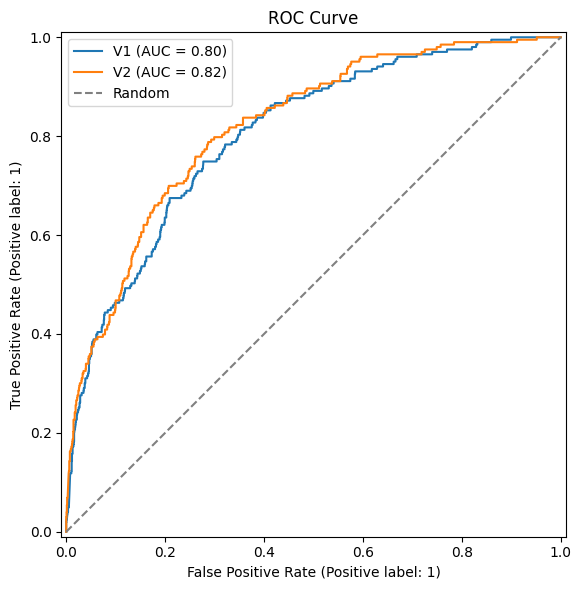

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(Y_test, Y_prob_v1, ax=ax, name="V1")
RocCurveDisplay.from_predictions(Y_test, Y_prob_v2, ax=ax, name="V2")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_title("ROC Curve")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/roc_curve.png", dpi=150)
plt.show()

Correlation with StatsBomb xG — Model V1: 0.8228  Model V2: 0.8725


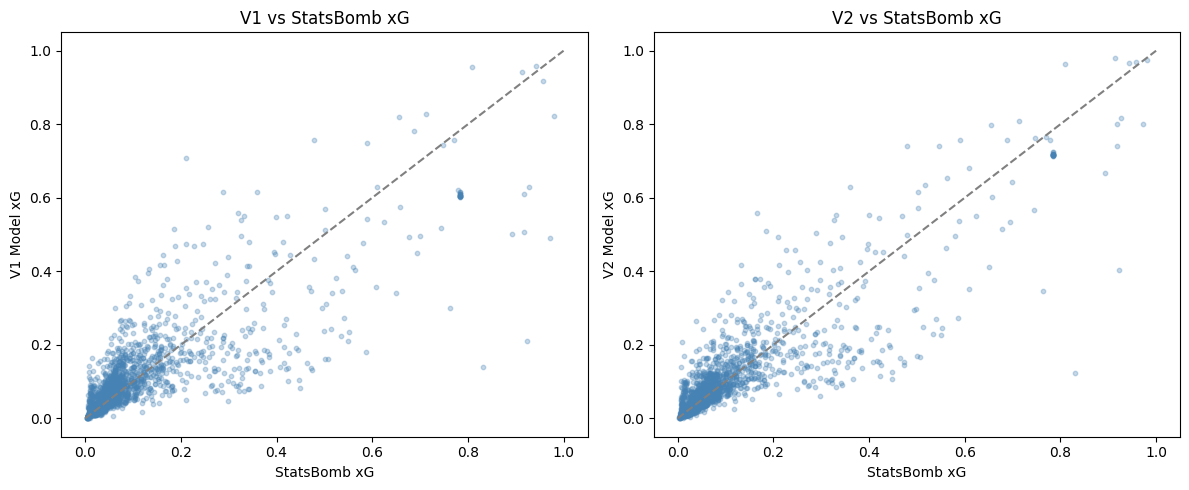

In [9]:
sb_xg = df_v1.loc[X1_test.index, "shot_statsbomb_xg"]
corr_v1 = np.corrcoef(sb_xg, Y_prob_v1)[0, 1]
corr_v2 = np.corrcoef(sb_xg, Y_prob_v2)[0, 1]
print(f"Correlation with StatsBomb xG — Model V1: {corr_v1:.4f}  Model V2: {corr_v2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_prob, label in zip(axes, [Y_prob_v1, Y_prob_v2], ["V1", "V2"]):
    ax.scatter(sb_xg, y_prob, alpha=0.3, s=10, color="steelblue")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_xlabel("StatsBomb xG")
    ax.set_ylabel(f"{label} Model xG")
    ax.set_title(f"{label} vs StatsBomb xG")
plt.tight_layout()
plt.savefig("outputs/xg_comparison_scatter.png", dpi=150)
plt.show()

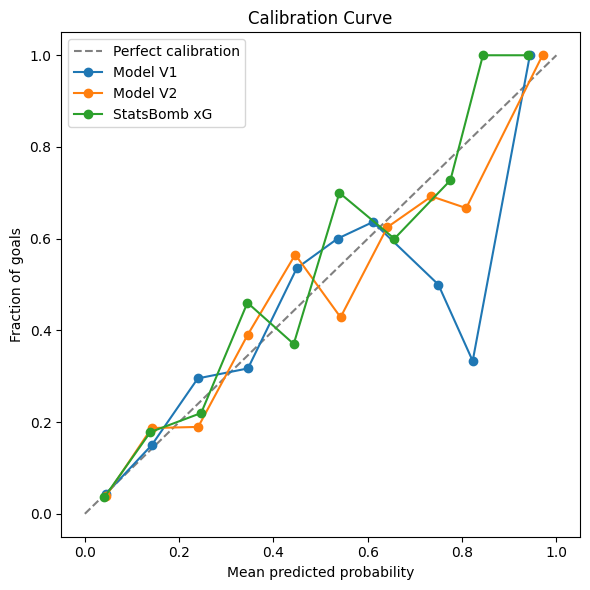

In [10]:
sb_xg_full = df_v1.loc[X1_test.index, "shot_statsbomb_xg"]
prob_true_v1, prob_pred_v1 = calibration_curve(Y_test, Y_prob_v1, n_bins=10)
prob_true_v2, prob_pred_v2 = calibration_curve(Y_test, Y_prob_v2, n_bins=10)
prob_true_sb, prob_pred_sb = calibration_curve(Y_test, sb_xg_full, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(prob_pred_v1, prob_true_v1, marker="o", label="Model V1")
ax.plot(prob_pred_v2, prob_true_v2, marker="o", label="Model V2")
ax.plot(prob_pred_sb, prob_true_sb, marker="o", label="StatsBomb xG")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of goals")
ax.set_title("Calibration Curve")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/calibration_curve.png", dpi=150)
plt.show()

## Model Interpretation

_You can find the graphs for each model under the outputs directory. Each model has a ROC curve, a comparison scatter plot, and a calibration curve_

### V1 Model
The V1 logistic regression model uses features such as distance, angle, is_header, is_open_play. It underestimates probability on high-quality chances (predicted >0.6), and is overconfident on shots the model assigns 0.8 xG convert at approximately 30% in reality. The StatsBomb's model
uses features unavailable in this first version of my model, and those missing features drive the difference on genuine big chances.

The negative coefficient (-1.73) for is_open_play is counterintuitive but correct,since the feature groups penalties with corners and free kicks under is_open_play = 0. Penalties convert at ~75–80% from a fixed central position; controlling for distance
and angle, the model correctly learns that non-open-play shots outperform their spatial position. A cleaner implementation would separate is_penalty as a distinct feature — this is the primary candidate for V2.